# 12 — Ablation CNN 2D et cartes d'activation

Chaque expérience modifie un seul facteur par rapport à la référence : padding, pas de la première convolution, type de pooling, capacité ou convolution ponctuelle 1 × 1. Tous les autres hyperparamètres restent ceux de `src.config`. Le classement des architectures repose exclusivement sur le macro-F1 de validation.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import *
from src.helpers import count_parameters, set_seed

set_seed(RANDOM_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Périphérique sélectionné :", device)
print("CUDA disponible :", torch.cuda.is_available())

Périphérique sélectionné : cuda
CUDA disponible : True


In [2]:
from src.models import WESADScalogramCNN
from src.scalograms import WESADScalogramDataset
from src.experiments import evaluate_frozen_test_model, run_validation_selected_experiment
from src.visualization import extract_feature_maps

scalogram_dir = PROJECT_ROOT / "data/processed/scalograms"
metadata_dir = PROJECT_ROOT / "data/processed/metadata"
ABlations = {
    "baseline": dict(padding=1, conv_stride=1, pooling_type="max", filters=(16, 32, 64), use_pointwise_conv=False),
    "padding_0": dict(padding=0, conv_stride=1, pooling_type="max", filters=(16, 32, 64), use_pointwise_conv=False),
    "stride_2_first_conv": dict(padding=1, conv_stride=2, pooling_type="max", filters=(16, 32, 64), use_pointwise_conv=False),
    "avg_pool": dict(padding=1, conv_stride=1, pooling_type="avg", filters=(16, 32, 64), use_pointwise_conv=False),
    "filters_8_16_32": dict(padding=1, conv_stride=1, pooling_type="max", filters=(8, 16, 32), use_pointwise_conv=False),
    "pointwise_1x1": dict(padding=1, conv_stride=1, pooling_type="max", filters=(16, 32, 64), use_pointwise_conv=True),
}
pd.DataFrame(ABlations).T

,padding,conv_stride,pooling_type,filters,use_pointwise_conv
baseline,1,1,max,"(16, 32, 64)",False
padding_0,0,1,max,"(16, 32, 64)",False
stride_2_first_conv,1,2,max,"(16, 32, 64)",False
avg_pool,1,1,avg,"(16, 32, 64)",False
filters_8_16_32,1,1,max,"(8, 16, 32)",False
pointwise_1x1,1,1,max,"(16, 32, 64)",True


Le pas 2 est appliqué uniquement à la première convolution. La référence avec pas 1, les deux valeurs de padding, les deux poolings, les deux capacités et l'ajout 1 × 1 forment des comparaisons contrôlées.

In [3]:
RUN_ABLATIONS = True
ablation_results = {}
if RUN_ABLATIONS:
    datasets = tuple(WESADScalogramDataset(
        scalogram_dir / f"X_{split}.pt",
        scalogram_dir / f"y_{split}.pt",
        metadata_dir / f"windows_{split}.csv",
    ) for split in ("train", "validation", "test"))
    validation_meta = pd.read_csv(metadata_dir / "windows_validation.csv")
    test_meta = pd.read_csv(metadata_dir / "windows_test.csv")
    for name, architecture in ABlations.items():
        factory = lambda architecture=architecture: WESADScalogramCNN(**architecture)
        ablation_results[name] = run_validation_selected_experiment(
            factory, datasets, validation_meta, test_meta,
            PROJECT_ROOT / "artifacts/models/cnn2d_ablations" / name,
            {
                "model_class": "WESADScalogramCNN", "architecture": architecture,
                "seed": RANDOM_SEED, "subject_split": SPLIT_SUBJECTS,
                "input_channels": SCALOGRAM_CHANNELS, "input_shape": [3, 64, 64],
                "normalization_statistics": "artifacts/preprocessing/scalograms/scalogram_metadata.json",
            }, device, compare_weighted_loss=False, evaluate_test=False,
        )
    selected_ablation = max(
        ablation_results,
        key=lambda name: ablation_results[name]["validation_metrics"]["macro_f1"],
    )
    ablation_results[selected_ablation] = evaluate_frozen_test_model(
        ablation_results[selected_ablation],
        datasets,
        test_meta,
        PROJECT_ROOT / "artifacts/models/cnn2d_ablations" / selected_ablation,
        device,
    )
    print("Architecture sélectionnée sur validation :", selected_ablation)
else:
    print("Non exécuté : activer RUN_ABLATIONS après le notebook 10.")

Epoch 001/100 | train_loss=0.4788 | validation_loss=0.4553 | best_epoch=1 *


Epoch 002/100 | train_loss=0.2868 | validation_loss=0.4089 | best_epoch=2 *


Epoch 003/100 | train_loss=0.2132 | validation_loss=0.3836 | best_epoch=3 *


Epoch 004/100 | train_loss=0.2041 | validation_loss=0.4341 | best_epoch=3


Epoch 005/100 | train_loss=0.1666 | validation_loss=0.5059 | best_epoch=3


...

Epoch 010/100 | train_loss=0.1002 | validation_loss=0.5238 | best_epoch=3


Epoch 011/100 | train_loss=0.0755 | validation_loss=0.6215 | best_epoch=3


Epoch 012/100 | train_loss=0.0694 | validation_loss=0.5387 | best_epoch=3


Epoch 013/100 | train_loss=0.0706 | validation_loss=0.6669 | best_epoch=3
Early stopping after 13 epochs (no validation-loss improvement for 10 epochs).


Architecture sélectionnée sur validation : baseline


## Tableau d'ablation CNN 2D

In [4]:
def artifact_row(name, path):
    with open(path / "model_config.json", encoding="utf-8") as f: config = json.load(f)
    with open(path / "validation_metrics.json", encoding="utf-8") as f: val = json.load(f)
    test_path = path / "test_metrics.json"
    test = json.loads(test_path.read_text(encoding="utf-8")) if test_path.exists() else {}
    with open(path / "training_summary.json", encoding="utf-8") as f: summary = json.load(f)
    arch = config.get("architecture", {})
    return {
        "model": name, "input representation": config.get("input_shape", "raw signals"),
        "padding": arch.get("padding"), "stride": arch.get("conv_stride"),
        "pooling": arch.get("pooling_type"), "filters": arch.get("filters"),
        "1x1 convolution": arch.get("use_pointwise_conv"),
        "parameter count": config.get("parameter_count"), "best epoch": summary.get("best_epoch"),
        "validation macro F1": val.get("macro_f1"), "test macro F1": test.get("macro_f1"),
        "stress precision": test.get("stress_precision"), "stress recall": test.get("stress_recall"),
        "ROC-AUC": test.get("roc_auc"), "average precision": test.get("average_precision"),
        "training time": summary.get("training_time_seconds"),
        "test inference time": test.get("inference_time_seconds"),
    }

paths = {name: PROJECT_ROOT / "artifacts/models/cnn2d_ablations" / name for name in ABlations}
rows = [artifact_row(name, path) for name, path in paths.items() if (path / "model_config.json").exists()]
ablation_table = pd.DataFrame(rows)
display(ablation_table.sort_values("validation macro F1", ascending=False) if len(ablation_table) else "Aucun artefact d'ablation.")

,model,input representation,padding,stride,pooling,filters,1x1 convolution,parameter count,best epoch,validation macro F1,test macro F1,stress precision,stress recall,ROC-AUC,average precision,training time,test inference time
0,baseline,"[3, 64, 64]",1,1,max,"[16, 32, 64]",False,89473,10,0.855924,0.8981,0.877049,0.835938,0.971922,0.938639,5.628323,0.032303
2,stride_2_first_conv,"[3, 64, 64]",1,2,max,"[16, 32, 64]",False,89473,2,0.837019,NaN,NaN,NaN,NaN,NaN,2.517431,NaN
5,pointwise_1x1,"[3, 64, 64]",1,1,max,"[16, 32, 64]",True,58785,3,0.823176,NaN,NaN,NaN,NaN,NaN,3.495604,NaN
4,filters_8_16_32,"[3, 64, 64]",1,1,max,"[8, 16, 32]",False,39041,3,0.812590,NaN,NaN,NaN,NaN,NaN,2.826598,NaN
1,padding_0,"[3, 64, 64]",0,1,max,"[16, 32, 64]",False,89473,6,0.811308,NaN,NaN,NaN,NaN,NaN,3.820126,NaN
3,avg_pool,"[3, 64, 64]",1,1,avg,"[16, 32, 64]",False,89473,3,0.783069,NaN,NaN,NaN,NaN,NaN,3.415476,NaN


## Cartes d'activation

Les hooks sont retirés immédiatement après l'inférence. Les images ci-dessous sont des activations apprises, et non une preuve physiologique directe. Une formulation prudente est : « cette carte répond fortement à un motif temps-fréquence localisé ». Les réponses peuvent coïncider avec des structures BVP périodiques, des variations EDA lentes, une activité d'accélération rapide ou des bandes larges/étroites, sans autoriser une interprétation causale.

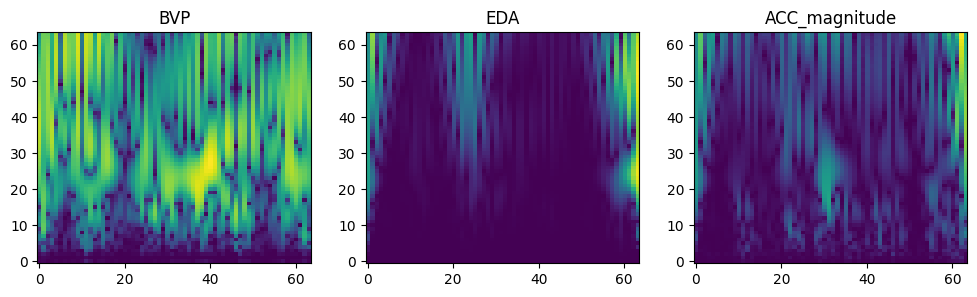

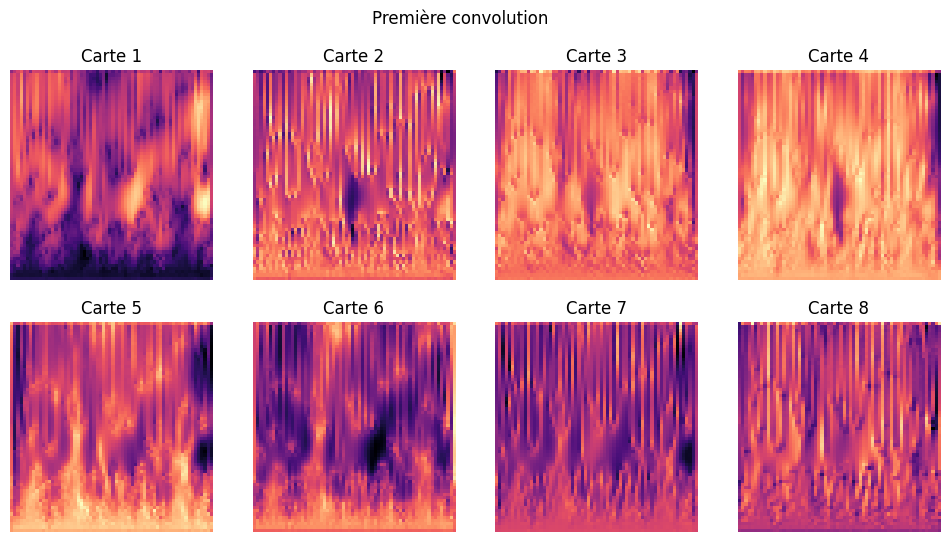

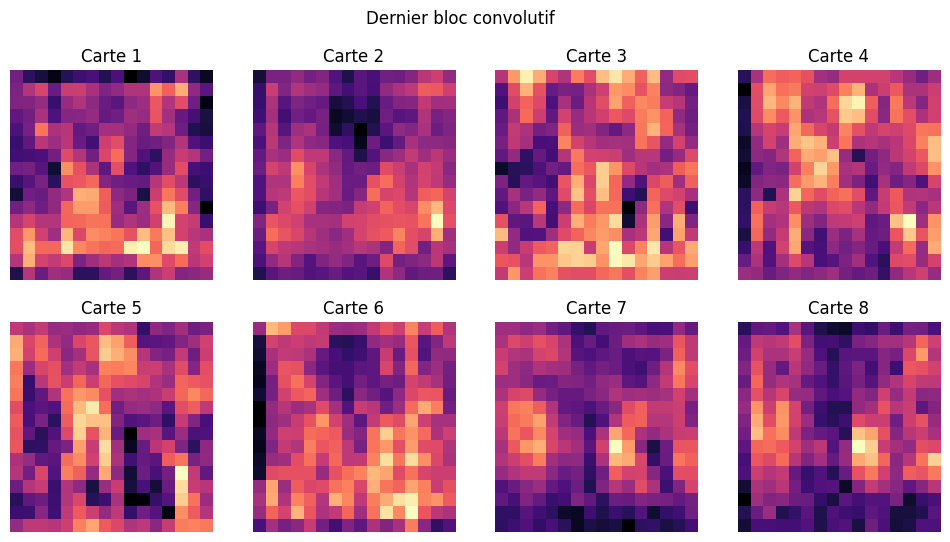

In [5]:
feature_checkpoint = PROJECT_ROOT / "artifacts/models/cnn2d/best_model.pt"
RUN_FEATURE_MAPS = feature_checkpoint.exists()
if RUN_FEATURE_MAPS:
    dataset = WESADScalogramDataset(scalogram_dir / "X_validation.pt", scalogram_dir / "y_validation.pt", metadata_dir / "windows_validation.csv")
    example, label, metadata = dataset[0]
    model = WESADScalogramCNN().to(device)
    model.load_state_dict(torch.load(feature_checkpoint, map_location=device, weights_only=True))
    maps = extract_feature_maps(model, example[None], [model.features[0], model.features[8]])
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    for i, channel in enumerate(SCALOGRAM_CHANNELS):
        axes[i].imshow(example[i], aspect="auto", origin="lower", cmap="viridis"); axes[i].set_title(channel)
    plt.show()
    for title, activation in zip(["Première convolution", "Dernier bloc convolutif"], maps):
        count = min(8, activation.shape[1]); fig, axes = plt.subplots(2, 4, figsize=(12, 6));
        for i, ax in enumerate(axes.flat):
            ax.axis("off")
            if i < count: ax.imshow(activation[0, i], aspect="auto", origin="lower", cmap="magma"); ax.set_title(f"Carte {i+1}")
        fig.suptitle(title); plt.show()